In [208]:
#!python -m pip install --upgrade pip
#%pip install pandas matplotlib seaborn scikit-learn openpyxl tensorflow xgboost aif360
#%pip install "aif360[Reductions, inFairness]"

In [209]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from pprint import pprint
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact
from fairlearn.metrics import MetricFrame, demographic_parity_difference, demographic_parity_ratio, selection_rate
from sklearn.preprocessing import LabelEncoder

random_seed = 15

In [210]:
PATH = 'C:/Users/andre/Desktop/ProjectWork_AEQUITAS_AKKODIS/'
df = (
    pd.read_excel(PATH + 'data/Dataset_2.0_Akkodis.xlsx')
      .rename(columns=lambda c: c.lstrip().title())
)
df.head()

,Id,Candidate State,Age Range,Residence,Sex,Protected Category,Tag,Study Area,Study Title,Years Experience,...,Akkodis Headquarters,Current Ral,Expected Ral,Technical Skills,Standing/Position,Comunication,Maturity,Dynamism,Mobility,English
0,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,2.0,2.0,1.0,2.0,2.0,3.0,3.0
4,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [211]:
config = {}
config['drop_columns'] = [
    'Id', 'Tag', 'Year Of Insertion',
    'Year Of Recruitment', 'Recruitment Request', 'Assumption Headquarters',
    'Event_Type__Val', 'Linked_Search__Key', 'Job Description', 
    'Candidate Profile', 'Akkodis Headquarters', 'Standing/Position', 'Last Role', 'Study Area.1',
    'Years Experience.1']
config['drop_rows'] = {
    'Candidate State': ['First contact', 'Imported']
}
config['remap_rows'] = {
    'Protected Category': {
        'Article 18': 'Yes',
        'Article 1': 'Yes'
    },
    'Residence': {
        'Türkiye » (STATE) ~ (OVERSEAS)' : 'TURKEY » (STATE) ~ (OVERSEAS)', 
        'ETHIOPIA': 'ETHIOPIA » (STATE) ~ (FOREIGN)',
        'SOUTH AFRICAN REPUBLIC': 'SOUTH AFRICAN REPUBLIC » (STATE) ~ (FOREIGN)',
        'USSR': 'USSR » (STATE) ~ (FOREIGN)',
        'YUGOSLAVIA': 'YUGOSLAVIA » (STATE) ~ (FOREIGN)'
    },
    'Study Area' : {
        'Automation/Mechatronics Engineering': 'Engineering',
        'computer engineering': 'Engineering',
        'chemical engineering': 'Engineering',
        'Legal': 'Law',
        'Mechanical engineering': 'Engineering',
        'Telecommunications Engineering': 'Engineering',
        'Economic - Statistics': 'Economic',
        'Psychology': 'Scientific Field',
        'Materials Science and Engineering': 'Engineering',
        'Other scientific subjects': 'Scientific Field',
        'Biomedical Engineering': 'Engineering',
        'electronic Engineering': 'Engineering',
        'Information Engineering': 'Engineering',
        'Aeronautical/Aerospace/Astronautics Engineering': 'Engineering',
        'Energy and Nuclear Engineering': 'Engineering',
        'Informatics': 'Informatics',
        'Management Engineering': 'Engineering',
        'Automotive Engineering': 'Engineering',
        'industrial engineering': 'Engineering',
        'Other': 'Other',
        'Surveyor': 'NO COLLEGE',
        'Civil/Civil and Environmental Engineering': 'Engineering',
        'Electrical Engineering': 'Engineering',
        'Scientific maturity': 'NO COLLEGE',
        'Chemist - Pharmaceutical': 'Medical Field',
        'Political-Social': 'Other Humanities Subjects',
        'Other humanities subjects': 'Other Humanities Subjects',
        'Geo-Biological': 'Scientific Field',
        'Linguistics': 'Linguistics',
        'Agriculture and veterinary': 'Scientific Field',
        'Literary': 'Other Humanities Subjects',
        'Humanistic high school diploma': 'NO COLLEGE',
        'Accounting': 'NO COLLEGE',
        'Communication Sciences': 'Other Humanities Subjects',
        'Safety Engineering': 'Engineering',
        'Architecture': 'Scientific Field',
        'Mathematics': 'Scientific Field',
        'construction Engineering': 'Engineering',
        'Petroleum Engineering': 'Engineering',
        'Naval Engineering': 'Engineering',
        'Artistic': 'NO COLLEGE',
        'Not Specified': 'Other',
        'Mathematical-physical modeling for engineering': 'Engineering',
        'Engineering for the environment and the territory': 'Engineering',
        'Medical': 'Medical Field',
        'Defense and Security': 'Other',
        'Physical education': 'Other',
        'Statistics': 'Scientific Field',
        'Educational/training sciences': 'Other Humanities Subjects'
    }
}
config['fill_nan_columns'] = {
    'Protected Category': 'Not a protected category',
}
config['fill_nan_columns_post_analysis'] = {
    'Protected Category': 'Not a protected category',
    'Study Area': 'Not Specified',
    'Sector': 'Unemployed',
    'Job Family Hiring': 'Not Specified',
    'Job Title Hiring': 'Not Specified',
    'Event_Feedback': 'Not Specified',
    'Overall': 'Not Specified',
    'Minimum Ral': 'Not Specified',
    'Ral Maximum': 'Not Specified',
    'Study Level': 'Not Specified',
    'Current Ral': 'Not Specified',
    'Expected Ral': 'Not Specified',
    'Technical Skills': '%MEAN%',
    'Comunication': '%MEAN%',
    'Maturity': '%MEAN%',
    'Dynamism': '%MEAN%',
    'Mobility': '%MEAN%',
    'English': '%MEAN%'
}
config['drop_nan_columns_threshold'] = '100.0'
config['feature_remapping'] = {
    'Residence': {
        'lists': {
            'state':    {'src':'Residence', 'inc':['(STATE)','(COUNTRY)'], 'exc':['Not Specified'], 'split':(' » ', 0)                    },
            'city':     {'src':'Residence', 'exc':['(STATE)','(COUNTRY)','Not Specified'],          'split':(' » ', 0)                    },
            'province': {'src':'Residence', 'exc':['(STATE)','(COUNTRY)','Not Specified'],          'split':(' » ', 1), 'post':(' ~ ', 0) },
            'region':   {'src':'Residence', 'exc':['(STATE)','(COUNTRY)','Not Specified'],          'split':(' ~ ',-1)                    },
        },
        'fields': {
            'Residence City':     {'src':'Residence', 'list':'city',     'def':'Not Specified'},
            'Residence Province': {'src':'Residence', 'list':'province', 'def':'Not Specified'},
            'Residence Region':   {'src':'Residence', 'list':'region',   'def':'Not Specified'},
            'Residence State':    {'src':'Residence', 'list':'state',    'def':'ITALY'},
            'European Residence': {'src':'Residence State', 'in':'eu',    'y':'Yes','n':'No'},
            'Italian Residence':  {'src':'Residence State', 'eq':'ITALY', 'y':'Yes','n':'No'},
        },
        'eu': [
            'ALBANIA', 'AUSTRIA', 'BELARUS', 'BELGIUM', 'BULGARIA', 'CROATIA', 'CZECH REPUBLIC',
            'FRANCE', 'GERMANY', 'GREAT BRITAIN-NORTHERN IRELAND', 'GREECE', 'ITALY', 'LATVIA',
            'LITHUANIA', 'LUXEMBOURG', 'MALTA', 'MOLDOVA', 'MONACO', 'MONTENEGRO', 'NETHERLANDS',
            'NORWAY', 'POLAND', 'PORTUGAL', 'ROMANIA', 'RUSSIA', 'SAN MARINO', 'SERBIA', 'SLOVAKIA',
            'SLOVENIA', 'SPAIN', 'SWEDEN', 'SWITZERLAND', 'UKRAINE'
        ]
    }
}
config['status_positive_conditions'] = {
    'Candidate State': ['Hired', 'Economic proposal', 'QM'],
    'Event_Feedback': ['OK (live)', 'OK (waiting for departure)', 'OK (hired)']
}
config['categorical_columns_custom_orders'] = {
    'Candidate State': ['Imported', 'First contact', 'In selection', 'QM', 'Vivier', 'Economic proposal', 'Hired'],
    'Age Range': ['< 20 years', '20 - 25 years', '26 - 30 years', '31 - 35 years', '36 - 40 years', '40 - 45 years', '> 45 years'],
    'Years Experience': ['[0]', '[0-1]', '[1-3]', '[3-5]', '[5-7]', '[7-10]', '[+10]'],
    'Study Title': ['Middle school diploma', 'High school graduation', 'Professional qualification', 'Three-year degree', 'master\'s degree', 'Five-year degree', 'Doctorate'],
    'Study Level': ['Middle school diploma', 'High school graduation', 'Professional qualification', 'Three-year degree', 'master\'s degree', 'Five-year degree', 'Doctorate'],
    'Current Ral': ['Not available', '- 20 K', '20-22 K', '22-24 K', '24-26 K', '26-28 K', '28-30 K', '30-32 K', '32-34 K', '34-36 K', '36-38 K', '38-40 K', '40-42 K', '42-44 K', '44-46 K', '46-48 K', '48-50 K', '+ 50 K'],
    'Expected Ral': ['Not available', '- 20 K', '20-22 K', '22-24 K', '24-26 K', '26-28 K', '28-30 K', '30-32 K', '32-34 K', '34-36 K', '36-38 K', '38-40 K', '40-42 K', '42-44 K', '44-46 K', '46-48 K', '48-50 K', '+ 50 K'],
    'Ral Maximum': ['Not Avail.', '- 20K', '20K', '20-22K', '22-24K', '24-26K', '26-28K', '28-30K', '30-32K', '32-34K', '34-36K', '36-38K', '38-40K', '40-42K', '42-44K', '44-46K', '46-48K', '48-50k', '+50K'],
    'Minimum Ral': ['Not Avail.', '- 20K', '20K', '20-22K', '22-24K', '24-26K', '26-28K', '28-30K', '30-32K', '32-34K', '34-36K', '36-38K', '38-40K', '40-42K', '42-44K', '44-46K', '46-48K', '48-50K', '+50K'],
    'Overall' : ['~ 1 - Low', '1 - Low', '~ 2 - Medium', '2 - Medium', '~ 3 - High', '3 - High', '~ 4 - Top', '4 - Top'],
}
config['visualize_columns'] = [
    'Candidate State', 'Age Range', 'Sex', 'Protected Category', 'Study Area', 'Study Title', 'Years Experience', 'Current Ral', 'Expected Ral', 'Ral Maximum', 'Minimum Ral', 'Overall']
config['sensitive_columns'] = ['Sex', 'Age Range', 'Protected Category']
config['correlation_threshold'] = 0.7
config['chi_squared_p_value_threshold'] = 0.01
config['cramers_v_threshold'] = 0.2

## Data Preprocessing

### Clean Dataset

In [212]:
df = df.drop_duplicates(subset='Id', keep='last')
df.head()

,Id,Candidate State,Age Range,Residence,Sex,Protected Category,Tag,Study Area,Study Title,Years Experience,...,Akkodis Headquarters,Current Ral,Expected Ral,Technical Skills,Standing/Position,Comunication,Maturity,Dynamism,Mobility,English
5,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,3.0,2.0,2.0,3.0,3.0,2.0,4.0
11,21020,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,"-, C, C++, DO178, LABVIEW, SOFTWARE DEVELOPMENT",computer engineering,Five-year degree,[7-10],...,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,27054,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,PROCESS ENG.,chemical engineering,Five-year degree,[3-5],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,27966,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,"CISCO, NOC DAS SUPPORT, SOC",Legal,Five-year degree,[7-10],...,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,48399,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,"CALIBRATION, CAN, DYANALIZER, GT POWER, HIL, M...",Mechanical engineering,Five-year degree,[3-5],...,NaN,NaN,24-26 K,3.0,2.0,2.0,2.0,3.0,1.0,1.0


In [213]:
df = df.drop(columns=config['drop_columns'])
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Automation/Mechatronics Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,computer engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,chemical engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Legal,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Mechanical engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [214]:
for col, remove_list in config['drop_rows'].items():
    df = df[~df[col].isin(remove_list)]
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Automation/Mechatronics Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,computer engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,chemical engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Legal,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Mechanical engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [215]:
for col, mapping in config['remap_rows'].items():
    df[col] = df[col].replace(mapping)
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,Engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,Engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Law,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [216]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Candidate State -- ['Hired', 'Vivier', 'QM', 'In selection', 'Economic proposal']
Feature: Age Range -- ['31 - 35 years', '40 - 45 years', '36 - 40 years', '> 45 years', '26 - 30 years', '< 20 years', '20 - 25 years']
Feature: Residence -- ['TURIN » Turin ~ Piedmont', 'CONVERSANO » Bari ~ Puglia', 'CASERTA » Caserta ~ Campania', 'SESTO SAN GIOVANNI » Milan ~ Lombardy', 'MAZARA DEL VALLO » Trapani ~ Sicily', 'MILAN » Milan ~ Lombardy', 'CHIERI » Turin ~ Piedmont', 'MARINE » Rome ~ Lazio', 'FANO » Pesaro-Urbino ~ Marche', 'CAPANNOLI » Pisa ~ Tuscany', 'LANCIANO » Chieti ~ Abruzzo', 'LIVORNO » Livorno ~ Tuscany', 'ASCOLI SATRIANO » Foggia ~ Puglia', 'EMPOLI » Florence ~ Tuscany', 'VITERBO » Viterbo ~ Lazio', 'SAN GIULIANO TERME » Pisa ~ Tuscany', 'SUPERSANO » Lecce ~ Puglia', 'MAZZARINO » Caltanissetta ~ Sicily', 'CAPANNORI » Lucca ~ Tuscany', 'MASSA » Massa-Carrara ~ Tuscany', 'FLORENCE » Florence ~ Tuscany', 'GERMANY » (STATE) ~ (OVERSEAS)', 'BOLOGNA » Bologna ~ Emilia Romagna'

### Handle NANs

In [217]:
print(f'Columns that contain NaN values:\n {df.columns[df.isnull().any()].tolist()}')

for col in df.columns[df.isnull().any()].tolist():
  print(f'{col} values: {df[col].unique()} \n') # Analyze each NaN containing feature first to determine the default fill value

Columns that contain NaN values:
 ['Protected Category', 'Sector', 'Job Family Hiring', 'Job Title Hiring', 'Event_Feedback', 'Overall', 'Minimum Ral', 'Ral Maximum', 'Study Level', 'Current Ral', 'Expected Ral', 'Technical Skills', 'Comunication', 'Maturity', 'Dynamism', 'Mobility', 'English']
Protected Category values: [nan 'Yes'] 

Sector values: ['Automotive' 'Aeronautics' 'Consulting' 'Telecom' 'Others' 'Space'
 'Life sciences' nan 'Railway' 'Defence' 'Naval'
 'Services and Information Systems' 'Machining - Heavy Industry' 'Energy'
 'Oil and Gas'] 

Job Family Hiring values: ['Engineering' nan 'Support' 'Tech Consulting & Solutions'
 'Business & Sales' 'Enabling Function' 'Business Management & Sales'
 'Talent Acquisition'] 

Job Title Hiring values: ['Consultant' nan 'Support Advanced' 'Qualified Consultant' 'Team Leader'
 'Advanced Consultant' 'Business Manager' 'Junior Consultant' '???'
 'Junior Business Manager' 'Support' 'Senior Consultant'
 'Business Unit Director' 'Pharmace

In [218]:
unuseful_columns = []
for col in df.columns:
  null_count = df[col].isna().sum() / df.shape[0]
  if null_count > (float(config['drop_nan_columns_threshold'])/100):
    unuseful_columns.append(col)
  
df = df.drop(columns=unuseful_columns)
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,Engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,Engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Law,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [219]:
for col, filler in config['fill_nan_columns'].items():
    if filler == '%MEAN%':
        media = round(df[col].mean())
        df[col].fillna(media, inplace=True)
    else:
        df[col].fillna(filler, inplace=True)
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [220]:
print(f'There are {df.isnull().sum().sum()} NANs')

There are 22418 NANs


### Features Reformatting

In [221]:
print(df['Residence'].unique())

['TURIN » Turin ~ Piedmont' 'CONVERSANO » Bari ~ Puglia'
 'CASERTA » Caserta ~ Campania' 'SESTO SAN GIOVANNI » Milan ~ Lombardy'
 'MAZARA DEL VALLO » Trapani ~ Sicily' 'MILAN » Milan ~ Lombardy'
 'CHIERI » Turin ~ Piedmont' 'MARINE » Rome ~ Lazio'
 'FANO » Pesaro-Urbino ~ Marche' 'CAPANNOLI » Pisa ~ Tuscany'
 'LANCIANO » Chieti ~ Abruzzo' 'LIVORNO » Livorno ~ Tuscany'
 'ASCOLI SATRIANO » Foggia ~ Puglia' 'EMPOLI » Florence ~ Tuscany'
 'VITERBO » Viterbo ~ Lazio' 'SAN GIULIANO TERME » Pisa ~ Tuscany'
 'SUPERSANO » Lecce ~ Puglia' 'MAZZARINO » Caltanissetta ~ Sicily'
 'CAPANNORI » Lucca ~ Tuscany' 'MASSA » Massa-Carrara ~ Tuscany'
 'FLORENCE » Florence ~ Tuscany' 'GERMANY » (STATE) ~ (OVERSEAS)'
 'BOLOGNA » Bologna ~ Emilia Romagna' 'PISA » Pisa ~ Tuscany'
 'CARRARA » Massa-Carrara ~ Tuscany' 'PONTEDERA » Pisa ~ Tuscany'
 'MODENA » Modena ~ Emilia Romagna' 'TARANTO » Taranto ~ Puglia'
 'CECINA » Livorno ~ Tuscany' 'MARSALA » Trapani ~ Sicily'
 'SEZZE » Latina ~ Lazio' 'MONZA » Monza-Bria

In [222]:
def gen_lists(df, specs):
    out = {}
    for name, p in specs.items():
        base = out.get(p['src'], df[p['src']].dropna().astype(str).unique())
        # filtra inc/exc
        items = [
            x for x in base
            if not any(exc in x for exc in p.get('exc', []))
               and (any(inc in x for inc in p.get('inc', [])) if 'inc' in p else True)
        ]
        # split / post-split
        for key in ('split', 'post'):
            if key in p:
                sep, idx = p[key]
                items = [x.split(sep)[idx] if sep in x else x for x in items]
        out[name] = sorted(set(items))
    return out

def apply_field(val, p, lists, feature_cfg):
    # pattern‐match su lista
    if 'list' in p:
        return next((x for x in lists[p['list']] if x in str(val)), p['def'])
    # appartenenza in lista
    if 'in' in p:
        return p['y'] if val in feature_cfg[p['in']] else p['n']
    # confronto esatto
    if 'eq' in p:
        return p['y'] if str(val) == p['eq'] else p['n']

for feature, feat_cfg in config['feature_remapping'].items():
    # Genera le liste specifiche
    lists = gen_lists(df, feat_cfg['lists'])
    # Mappa ogni campo
    for col_name, col_cfg in feat_cfg['fields'].items():
        df[col_name] = df[col_cfg['src']].apply(lambda v, cfg=col_cfg: apply_field(v, cfg, lists, feat_cfg))
    # Elimina le colonne originali
    df = df.drop(columns=feature, errors='ignore')

df.head()


,Candidate State,Age Range,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,Job Title Hiring,...,Maturity,Dynamism,Mobility,English,Residence City,Residence Province,Residence Region,Residence State,European Residence,Italian Residence
5,Hired,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,Consultant,...,3.0,3.0,2.0,4.0,TURIN,Turin,Piedmont,ITALY,Yes,Yes
11,Vivier,40 - 45 years,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,NaN,NaN,...,NaN,NaN,NaN,NaN,CONVERSANO,Bari,Puglia,ITALY,Yes,Yes
13,QM,36 - 40 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,NaN,NaN,...,NaN,NaN,NaN,NaN,CASERTA,Caserta,Campania,ITALY,Yes,Yes
17,QM,> 45 years,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,NaN,NaN,...,NaN,NaN,NaN,NaN,SESTO SAN GIOVANNI,Milan,Lombardy,ITALY,Yes,Yes
25,In selection,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,NaN,NaN,...,2.0,3.0,1.0,1.0,ARA,Trapani,Sicily,ITALY,Yes,Yes


In [223]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Candidate State -- ['Hired', 'Vivier', 'QM', 'In selection', 'Economic proposal']
Feature: Age Range -- ['31 - 35 years', '40 - 45 years', '36 - 40 years', '> 45 years', '26 - 30 years', '< 20 years', '20 - 25 years']
Feature: Sex -- ['Male', 'Female']
Feature: Protected Category -- ['Not a protected category', 'Yes']
Feature: Study Area -- ['Engineering', 'Law', 'Economic', 'Scientific Field', 'Informatics', 'Other', 'NO COLLEGE', 'Medical Field', 'Other Humanities Subjects', 'Linguistics']
Feature: Study Title -- ['Five-year degree', 'Doctorate', 'High school graduation', 'Three-year degree', "master's degree", 'Middle school diploma', 'Professional qualification']
Feature: Years Experience -- ['[1-3]', '[7-10]', '[3-5]', '[5-7]', '[+10]', '[0]', '[0-1]']
Feature: Sector -- ['Automotive', 'Aeronautics', 'Consulting', 'Telecom', 'Others', 'Space', 'Life sciences', nan, 'Railway', 'Defence', 'Naval', 'Services and Information Systems', 'Machining - Heavy Industry', 'Energy', '

### Identify Numerical and Categorical Columns

In [224]:
columns_type = {}
for col in df.columns:
    if pd.api.types.is_string_dtype(df[col]):
        columns_type[col] = 'cat'
    elif pd.api.types.is_numeric_dtype(df[col]):
        columns_type[col] = 'num'
pprint(columns_type)

{'Age Range': 'cat',
 'Candidate State': 'cat',
 'Comunication': 'num',
 'Dynamism': 'num',
 'English': 'num',
 'European Residence': 'cat',
 'Italian Residence': 'cat',
 'Maturity': 'num',
 'Mobility': 'num',
 'Protected Category': 'cat',
 'Residence City': 'cat',
 'Residence Province': 'cat',
 'Residence Region': 'cat',
 'Residence State': 'cat',
 'Sex': 'cat',
 'Study Area': 'cat',
 'Study Title': 'cat',
 'Technical Skills': 'num',
 'Years Experience': 'cat'}


## Target Column

In [225]:
mask = np.zeros(len(df), dtype=bool)
for col, valid_values in config['status_positive_conditions'].items():
    mask |= df[col].isin(valid_values)
df['Status'] = np.where(mask, 'Positive', 'Negative')
df.head()

,Candidate State,Age Range,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,Job Title Hiring,...,Dynamism,Mobility,English,Residence City,Residence Province,Residence Region,Residence State,European Residence,Italian Residence,Status
5,Hired,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,Consultant,...,3.0,2.0,4.0,TURIN,Turin,Piedmont,ITALY,Yes,Yes,Positive
11,Vivier,40 - 45 years,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,NaN,NaN,...,NaN,NaN,NaN,CONVERSANO,Bari,Puglia,ITALY,Yes,Yes,Negative
13,QM,36 - 40 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,NaN,NaN,...,NaN,NaN,NaN,CASERTA,Caserta,Campania,ITALY,Yes,Yes,Positive
17,QM,> 45 years,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,NaN,NaN,...,NaN,NaN,NaN,SESTO SAN GIOVANNI,Milan,Lombardy,ITALY,Yes,Yes,Positive
25,In selection,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,NaN,NaN,...,3.0,1.0,1.0,ARA,Trapani,Sicily,ITALY,Yes,Yes,Negative


In [226]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Candidate State -- ['Hired', 'Vivier', 'QM', 'In selection', 'Economic proposal']
Feature: Age Range -- ['31 - 35 years', '40 - 45 years', '36 - 40 years', '> 45 years', '26 - 30 years', '< 20 years', '20 - 25 years']
Feature: Sex -- ['Male', 'Female']
Feature: Protected Category -- ['Not a protected category', 'Yes']
Feature: Study Area -- ['Engineering', 'Law', 'Economic', 'Scientific Field', 'Informatics', 'Other', 'NO COLLEGE', 'Medical Field', 'Other Humanities Subjects', 'Linguistics']
Feature: Study Title -- ['Five-year degree', 'Doctorate', 'High school graduation', 'Three-year degree', "master's degree", 'Middle school diploma', 'Professional qualification']
Feature: Years Experience -- ['[1-3]', '[7-10]', '[3-5]', '[5-7]', '[+10]', '[0]', '[0-1]']
Feature: Sector -- ['Automotive', 'Aeronautics', 'Consulting', 'Telecom', 'Others', 'Space', 'Life sciences', nan, 'Railway', 'Defence', 'Naval', 'Services and Information Systems', 'Machining - Heavy Industry', 'Energy', '

## Visualize Data

In [227]:
stats = pd.DataFrame(index=df.columns)
stats['missing_values'] = df.isnull().sum()
stats['min'] = df.min(numeric_only=True)
stats['max'] = df.max(numeric_only=True)
stats['mean'] = df.mean(numeric_only=True)
stats['std'] = df.std(numeric_only=True)
stats['1st_percentile'] = df.quantile(0.25, numeric_only=True)
stats['2nd_percentile'] = df.quantile(0.50, numeric_only=True)
stats['3rd_percentile'] = df.quantile(0.75, numeric_only=True)
stats['type'] = df.dtypes
stats['distinct_values'] = df.nunique()
pprint(stats)

                    missing_values  min  max      mean       std  \
Candidate State                  0  NaN  NaN       NaN       NaN   
Age Range                        0  NaN  NaN       NaN       NaN   
Sex                              0  NaN  NaN       NaN       NaN   
Protected Category               0  NaN  NaN       NaN       NaN   
Study Area                       0  NaN  NaN       NaN       NaN   
Study Title                      0  NaN  NaN       NaN       NaN   
Years Experience                 0  NaN  NaN       NaN       NaN   
Sector                         217  NaN  NaN       NaN       NaN   
Job Family Hiring             2137  NaN  NaN       NaN       NaN   
Job Title Hiring              2137  NaN  NaN       NaN       NaN   
Event_Feedback                 932  NaN  NaN       NaN       NaN   
Overall                        964  NaN  NaN       NaN       NaN   
Minimum Ral                   2373  NaN  NaN       NaN       NaN   
Ral Maximum                   2310  NaN  NaN    

### Count

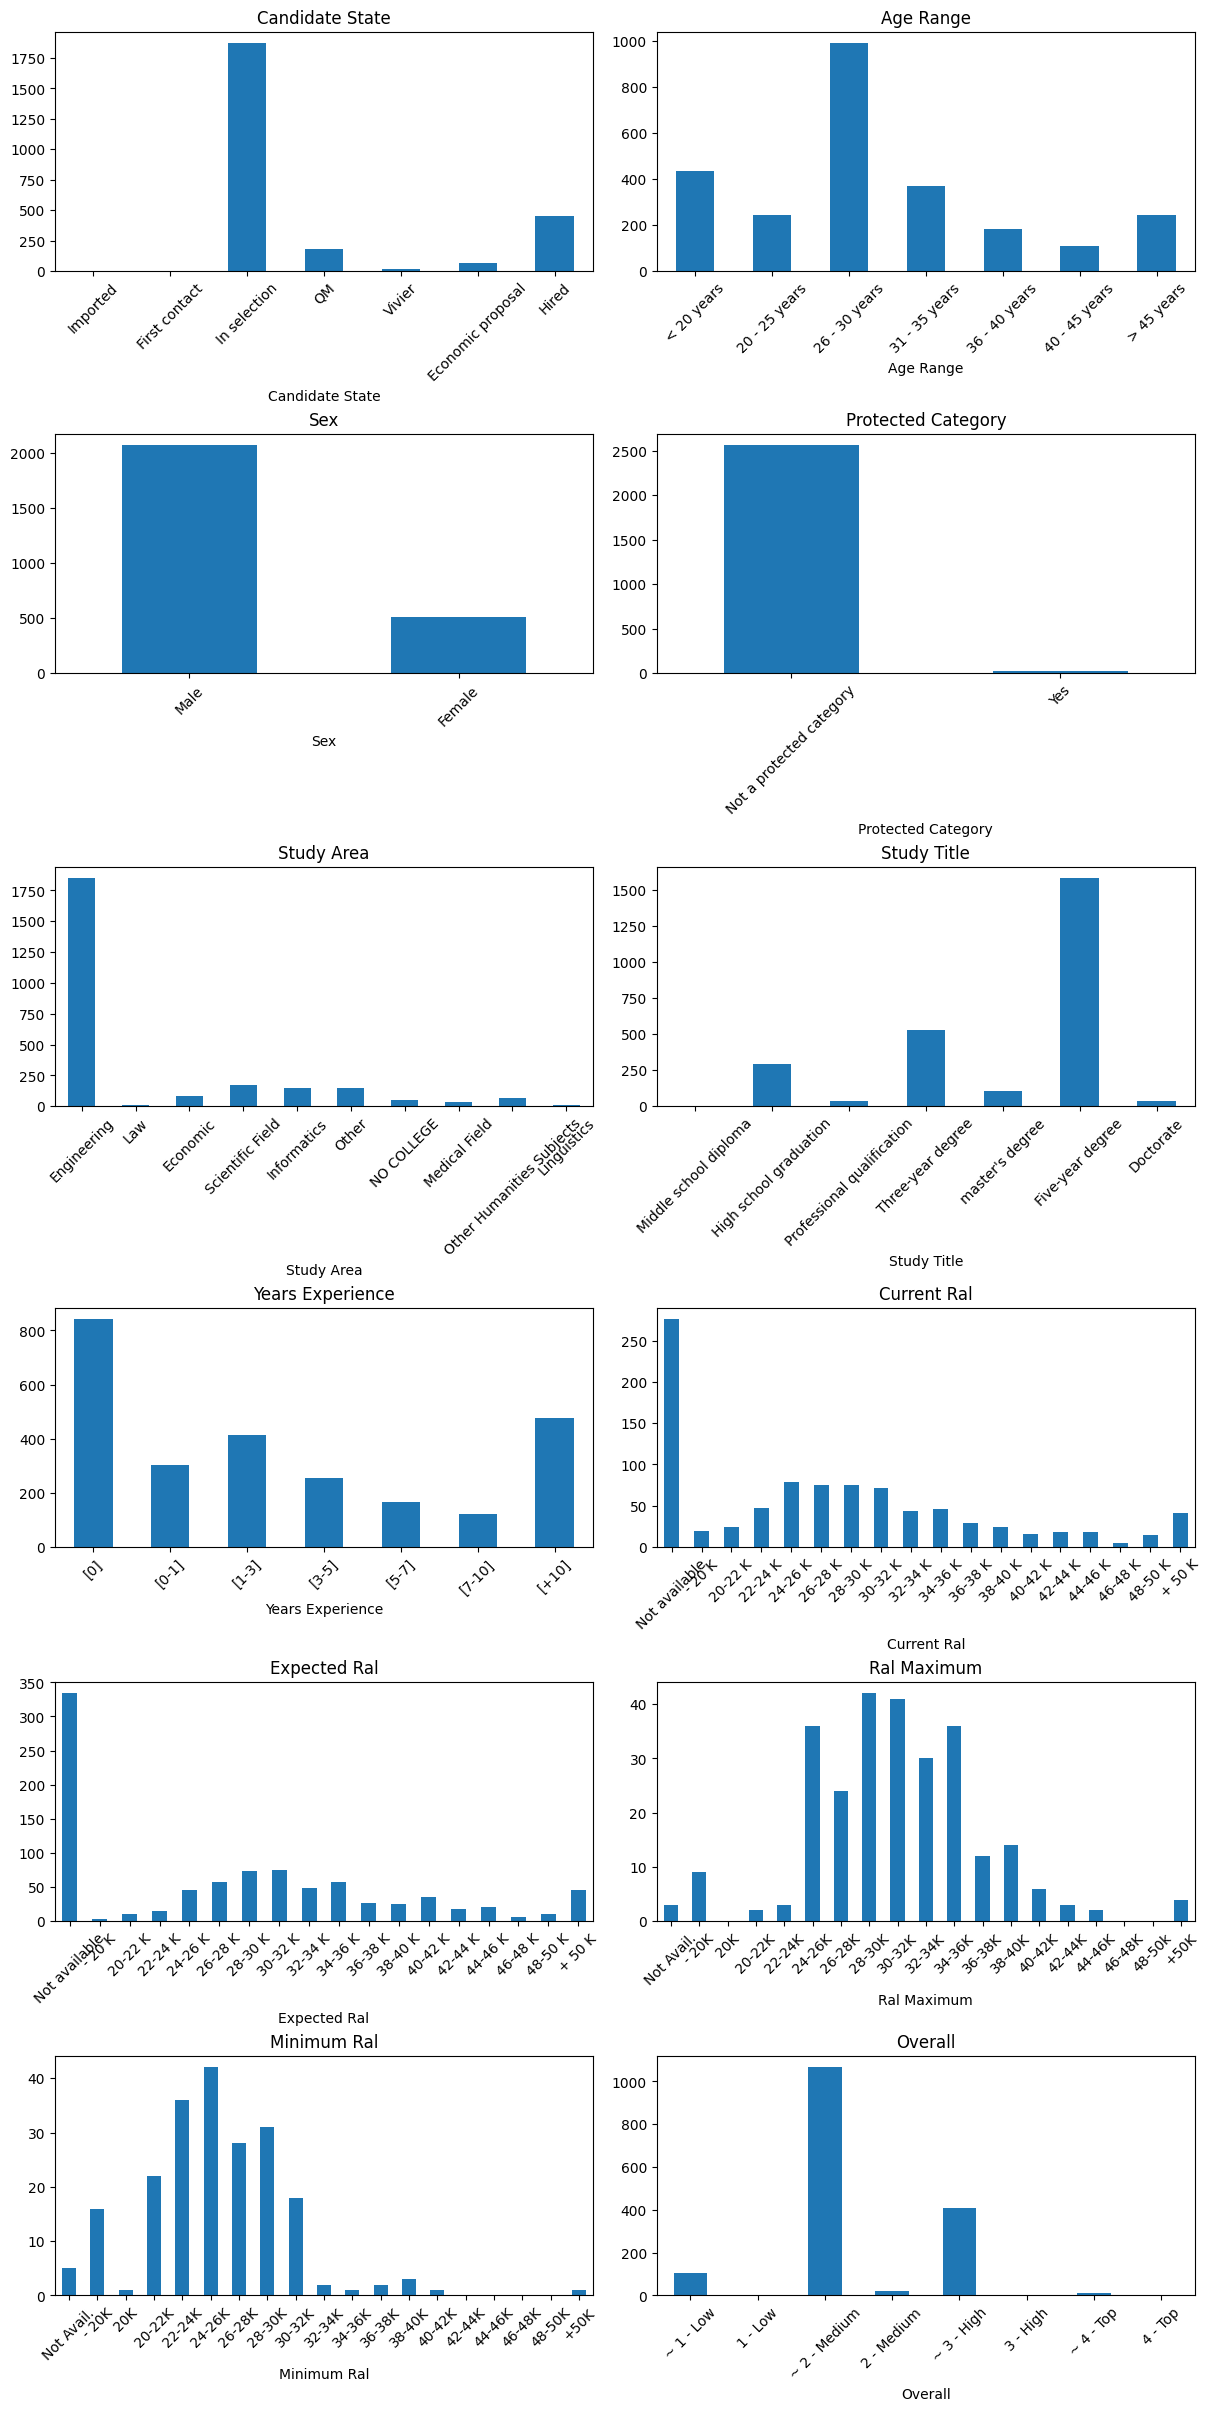

In [228]:
cols = 2  # numero di colonne nella griglia
n = len(config['visualize_columns'])
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4), constrained_layout=True)
axes = axes.flatten()
for i, lookup in enumerate(config['visualize_columns']):
    ax = axes[i]

    distrib = Counter(df[lookup])
    labels = config['categorical_columns_custom_orders'].get(lookup, list(distrib.keys()))
    counts = [distrib[label] for label in labels]
    distrib_df = pd.DataFrame({lookup: labels, 'Count': counts})

    distrib_df.plot(
        x=lookup,
        y='Count',
        kind='bar',
        legend=False,
        ax=ax
    )
    ax.set_title(lookup)
    ax.tick_params(axis='x', rotation=45)  # se vuoi ruotare le etichette

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.show()


### Visualize Distributions

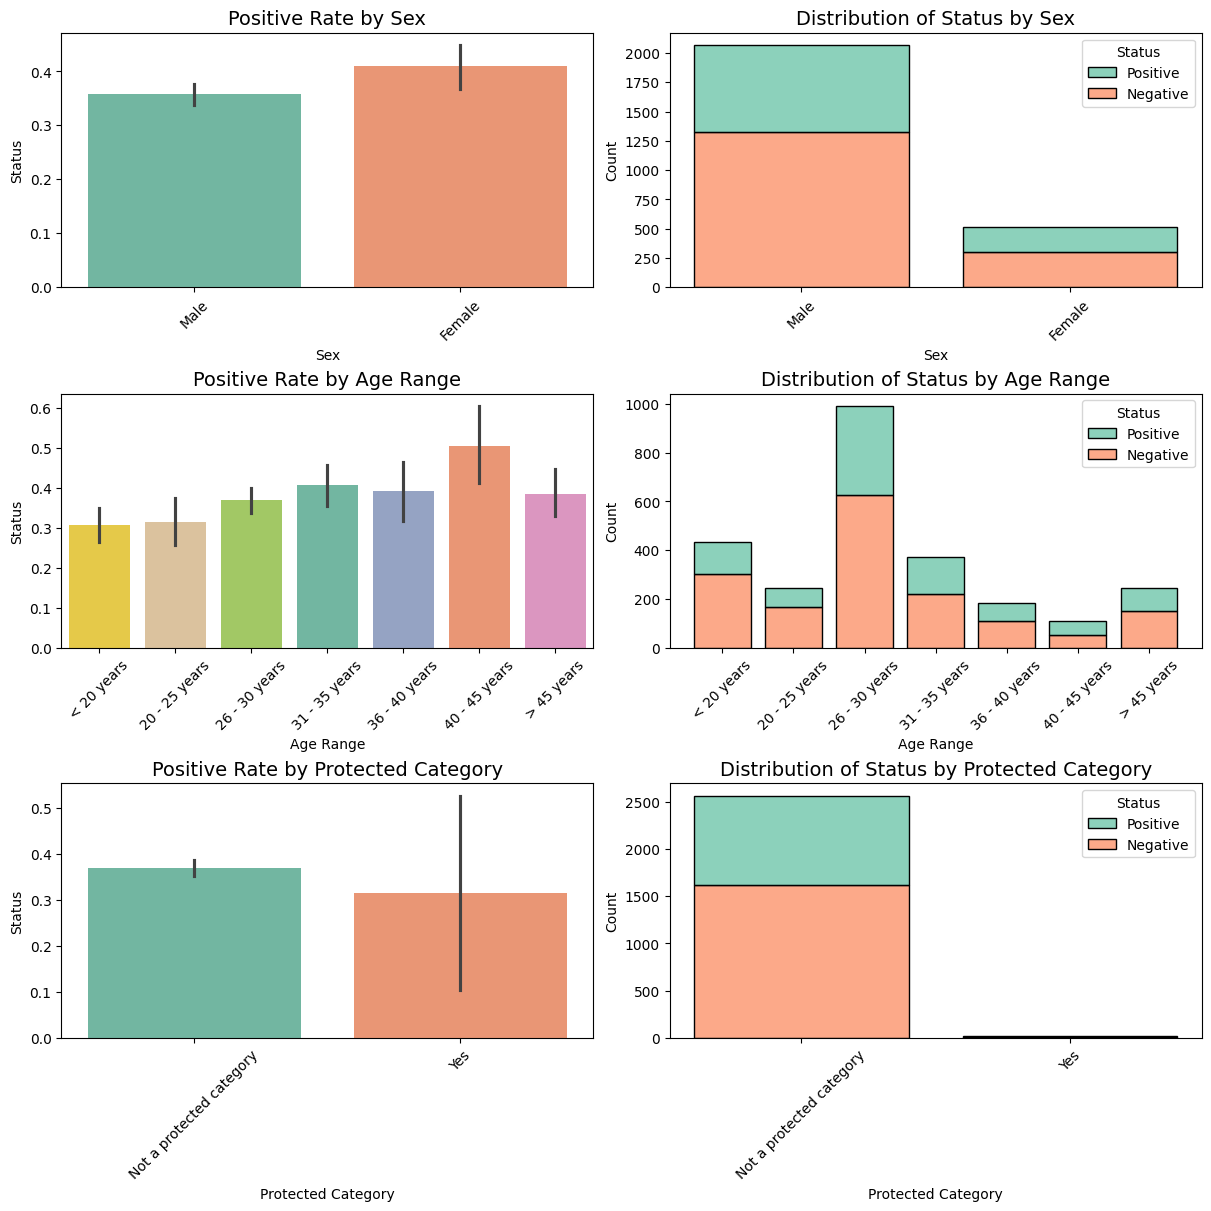

In [229]:
cols = 2  # numero di colonne nella griglia
n = len(config['sensitive_columns'])
total_plots = n * 2
rows = math.ceil(total_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4), constrained_layout=True)
axes = axes.flatten()
for i, snstv_col in enumerate(config['sensitive_columns']):
    order = config['categorical_columns_custom_orders'].get(snstv_col, None)

    df_plot = df.copy()
    if order:
        df_plot[snstv_col] = pd.Categorical(
            df_plot[snstv_col],
            categories=order,
            ordered=True
        )

    ax_hist = axes[2 * i + 1]
    sns.histplot(
        data=df_plot,
        x=snstv_col,
        hue="Status",
        multiple="stack",
        palette="Set2",
        shrink=0.8,
        ax=ax_hist
    )
    ax_hist.set_title(f"Distribution of Status by {snstv_col}", fontsize=14)
    ax_hist.tick_params(axis='x', rotation=45)

    
    ax_bar = axes[2 * i]
    sns.barplot(
        data=df,
        x=snstv_col,
        y=(df['Status'] == 'Positive').astype(float),
        estimator=np.mean,
        order=order,
        hue=snstv_col,
        palette='Set2',
        ax=ax_bar
    )
    ax_bar.set_title(f"Positive Rate by {snstv_col}", fontsize=14)
    ax_bar.tick_params(axis='x', rotation=45)

for j in range(2 * n, len(axes)):
    axes[j].axis('off')

plt.show()

## Handle NaNs post analysis

In [230]:
for col, filler in config['fill_nan_columns_post_analysis'].items():
    if filler == '%MEAN%':
        media = round(df[col].mean())
        df[col].fillna(media, inplace=True)
    else:
        df[col].fillna(filler, inplace=True)

In [231]:
print(f'There are {df.isnull().sum().sum()} NANs')

There are 0 NANs


## Save to File

In [232]:
df.to_excel(PATH + 'data/Dataset_Preprocessed.xlsx', index=False)

## Crosscorrelation

Text(0.5, 1.0, 'Correlation Matrix')

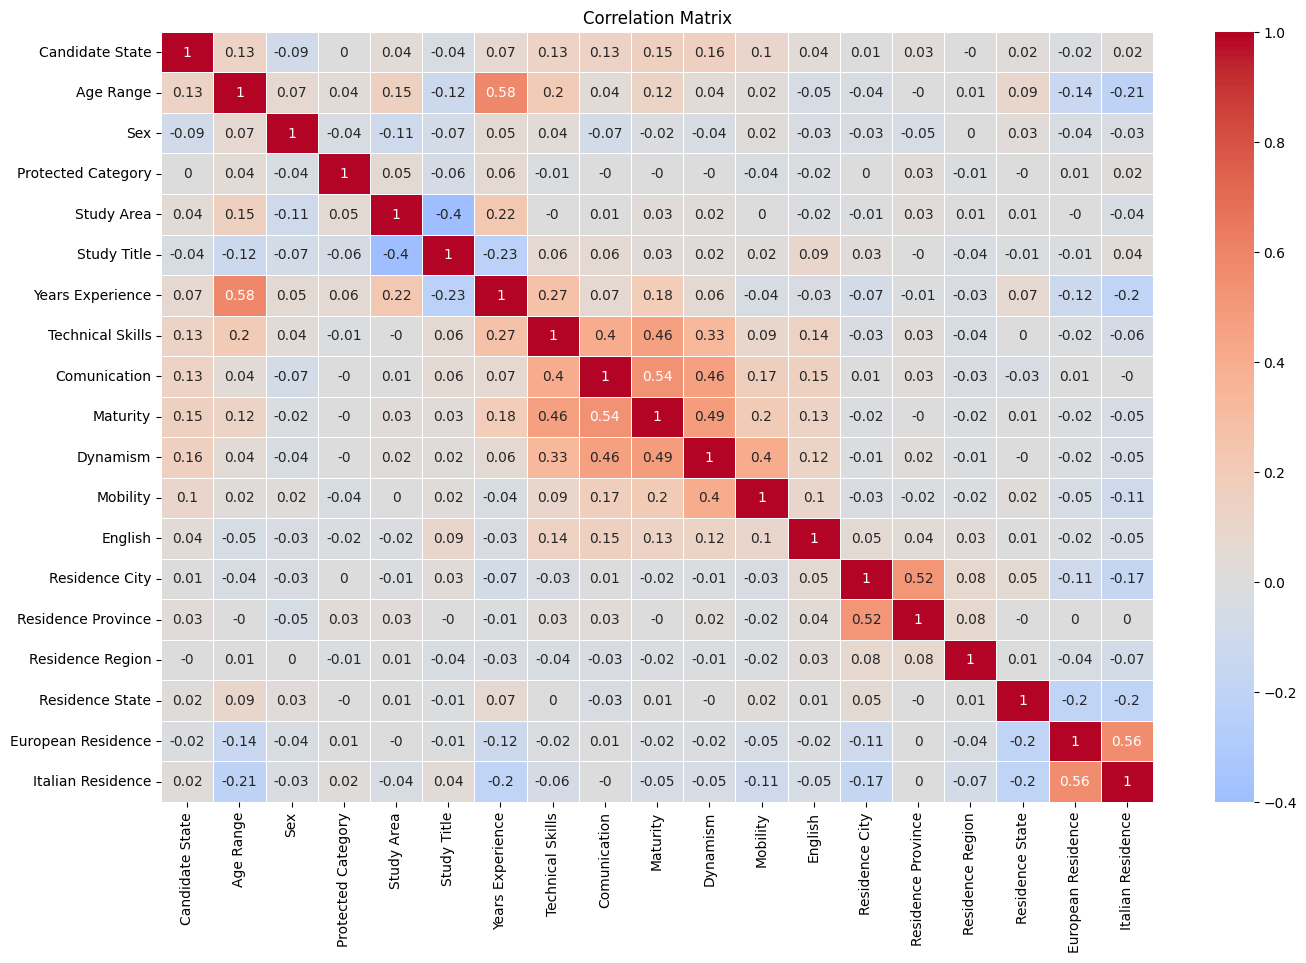

In [238]:
encoding_mappings = {}
df_corr = pd.DataFrame(index=df.index)
for col, t in columns_type.items():
    if t == 'cat':
        if col in config['categorical_columns_custom_orders']:
            ordered = config['categorical_columns_custom_orders'][col]
            df_corr[col] = pd.Categorical(df[col], categories=ordered, ordered=True).codes
            encoding_mappings[col] = {cat: i for i, cat in enumerate(ordered)}
        else:
            encoder = LabelEncoder()
            df_corr[col] = encoder.fit_transform(df[col].astype(str))
            encoding_mappings[col] = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
    else:
        df_corr[col] = df[col]

plt.figure(figsize=(16, 10))
sns.heatmap(df_corr.corr().round(2), annot=True, cmap='coolwarm', center=0, linewidths=.5)
plt.title("Correlation Matrix")

Text(0.5, 1.0, 'Correlation Matrix of Numerical and Ordered Categorical Features')

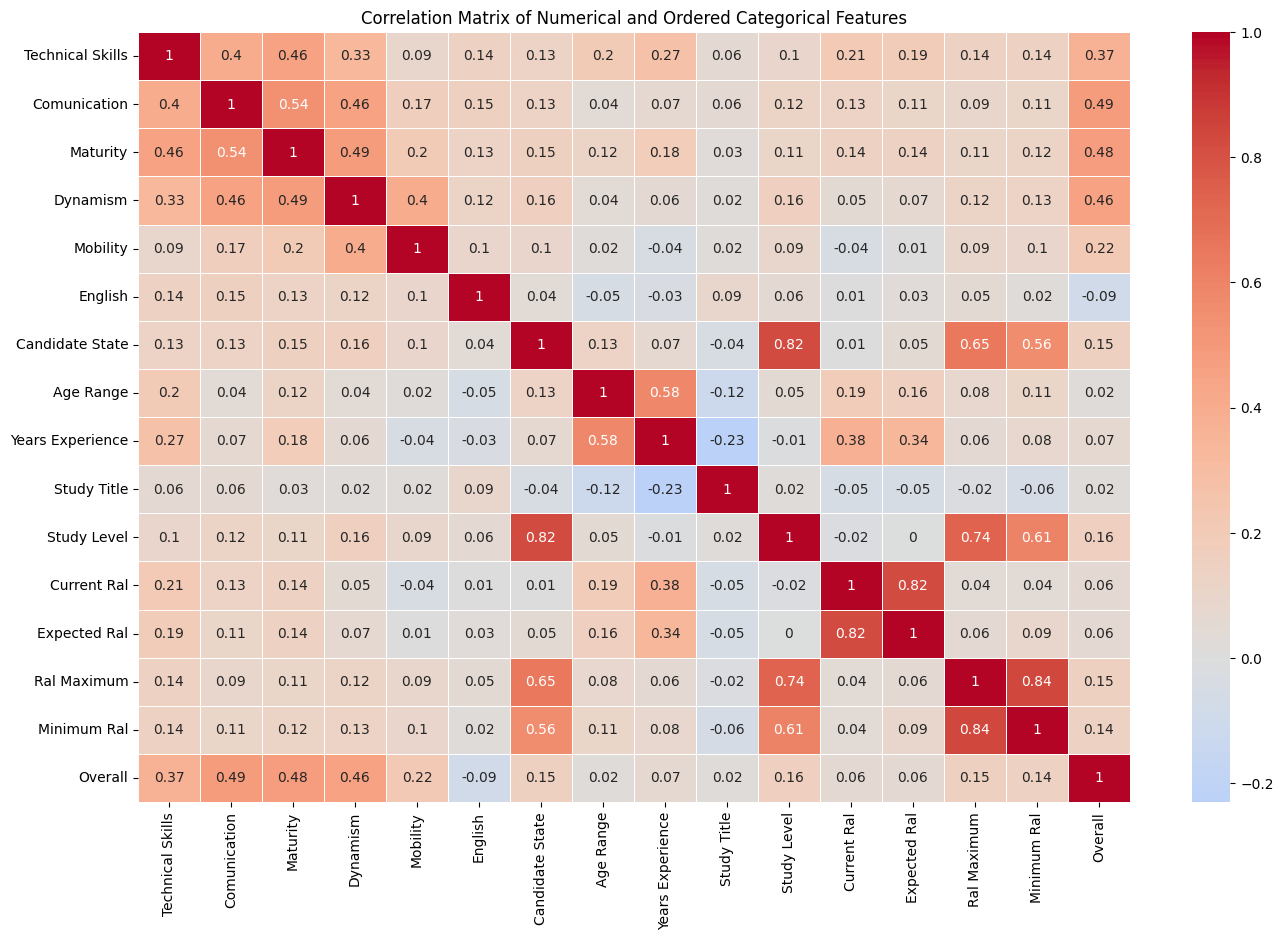

In [234]:
df_num = df.select_dtypes(include='number')

cat_cols = list(config['categorical_columns_custom_orders'].keys())

df_cat_encoded = pd.DataFrame(
    { col: pd.Categorical(df[col],
                          categories=config['categorical_columns_custom_orders'][col],
                          ordered=True
                         ).codes
      for col in cat_cols },
    index=df.index
)

df_corr = pd.concat([df_num, df_cat_encoded], axis=1)

plt.figure(figsize=(16, 10))
sns.heatmap(df_corr.corr().round(2), annot=True, cmap='coolwarm', center=0, linewidths=.5)
plt.title("Correlation Matrix of Numerical and Ordered Categorical Features")

In [235]:
corr_matrix = df_corr.corr().abs()

# Create a mask to get the upper triangle (excluding the diagonal)
upper_triangle_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
upper_triangle = corr_matrix.where(upper_triangle_mask)
corr_pairs = upper_triangle.stack()

high_corr_pairs = corr_pairs[corr_pairs > config['correlation_threshold']].sort_values(ascending=False)

print("Variable pairs with correlation above the threshold:")
print(high_corr_pairs)

Variable pairs with correlation above the threshold:
Ral Maximum      Minimum Ral     0.839071
Candidate State  Study Level     0.822850
Current Ral      Expected Ral    0.818242
Study Level      Ral Maximum     0.736592
dtype: float64


## Chi-squared Tests

In [236]:
def compute(col1, col2):
    order = config['categorical_columns_custom_orders'].get(col1, None)
    contingency = pd.crosstab(df[col1], df[col2])
    if order:
        contingency = contingency.reindex(index=order)
    chi2, p, dof, expected = chi2_contingency(contingency, correction=False)
    test_name = 'Chi-squared'
    if contingency.shape == (2, 2) and (expected < 5).any():
        _, p = fisher_exact(contingency)
        test_name = "Fisher's exact"
    n = contingency.values.sum()
    k = min(contingency.shape)
    cramer_v = np.sqrt(chi2 / (n * (k - 1)))

    return contingency, expected, chi2, p, dof, cramer_v, test_name

cats = [col for col, t in columns_type.items() if t == 'cat']
for col1, col2 in combinations(cats, 2):
    if col1 == col2:
        continue
    
    contingency, expected, chi2, p, dof, cramer_v, test_name = compute(col1, col2)

    if p < config['chi_squared_p_value_threshold'] and cramer_v >= config['cramers_v_threshold']:
        print(f"--- {col1} vs {col2} ---")
        #print("Actual frequencies:")
        #print(contingency)
        #print()
        #print("Expected frequencies:")
        #print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))
        #print()
        print(f"{test_name} test: χ² = {chi2:.2f}, p = {p:.3f}, dof = {dof}, Cramér’s V = {cramer_v:.3f}")
        print()

--- Age Range vs Years Experience ---
Chi-squared test: χ² = 2092.78, p = 0.000, dof = 36, Cramér’s V = 0.368

--- Age Range vs Residence City ---
Chi-squared test: χ² = 4873.20, p = 0.000, dof = 4440, Cramér’s V = 0.561

--- Age Range vs Residence Province ---
Chi-squared test: χ² = 1096.28, p = 0.000, dof = 666, Cramér’s V = 0.266

--- Age Range vs Italian Residence ---
Chi-squared test: χ² = 210.25, p = 0.000, dof = 6, Cramér’s V = 0.285

--- Sex vs Study Area ---
Chi-squared test: χ² = 214.75, p = 0.000, dof = 9, Cramér’s V = 0.288

--- Study Area vs Study Title ---
Chi-squared test: χ² = 1632.05, p = 0.000, dof = 54, Cramér’s V = 0.325

--- Study Area vs Residence Province ---
Chi-squared test: χ² = 1500.14, p = 0.000, dof = 999, Cramér’s V = 0.254

--- Study Title vs Residence City ---
Chi-squared test: χ² = 4828.69, p = 0.000, dof = 4440, Cramér’s V = 0.558

--- Study Title vs Residence Province ---
Chi-squared test: χ² = 991.30, p = 0.000, dof = 666, Cramér’s V = 0.253

--- Yea

## Bias Detection

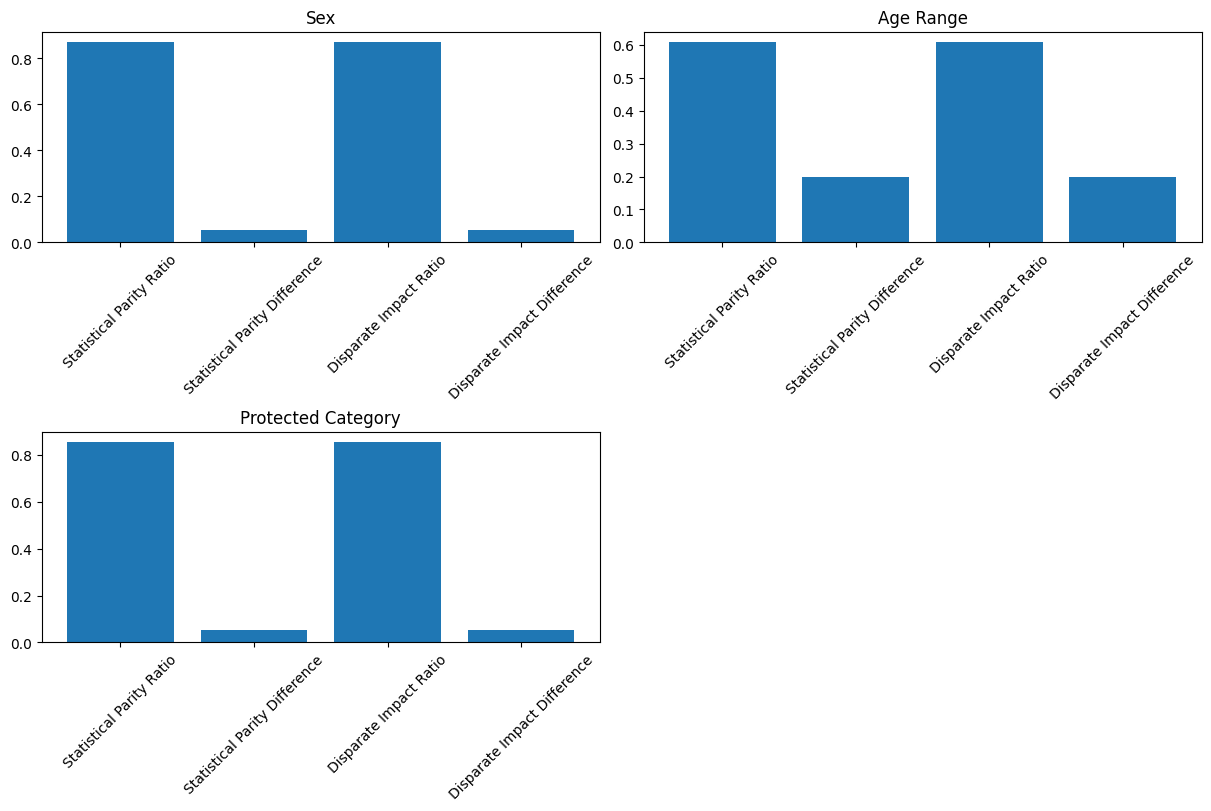

In [243]:
cols = 2
n = len(config['sensitive_columns'])
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4), constrained_layout=True)
axes = axes.flatten()

for i, sensitive_attr in enumerate(config['sensitive_columns']):
    y_true = (df["Status"] == 'Positive').astype(int)
    y_pred = y_true  # Measuring bias in the true labels
    s_attr = df[sensitive_attr]

    dpr = demographic_parity_ratio(y_true, y_pred, sensitive_features=s_attr)
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=s_attr)

    mf = MetricFrame(
        metrics=selection_rate,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=s_attr
    )
    sr_by_group = mf.by_group

    dir = sr_by_group.min() / sr_by_group.max()
    did = sr_by_group.max() - sr_by_group.min()

    # Plot dei 4 valori
    metrics = [dpr, dpd, dir, did]
    labels = ['Statistical Parity Ratio',
              'Statistical Parity Difference',
              'Disparate Impact Ratio',
              'Disparate Impact Difference']
    
    ax = axes[i]
    ax.bar(labels, metrics)
    ax.set_title(sensitive_attr)
    ax.tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.show()